--- Starting Divergence Analysis: 18 Scenarios vs LSTM Baseline ---
Success! Divergence chart saved at: E:\Projetos\ABMS-WP\figuras\figure-diferenca-cenarios-vs-lstm-fig11.pdf


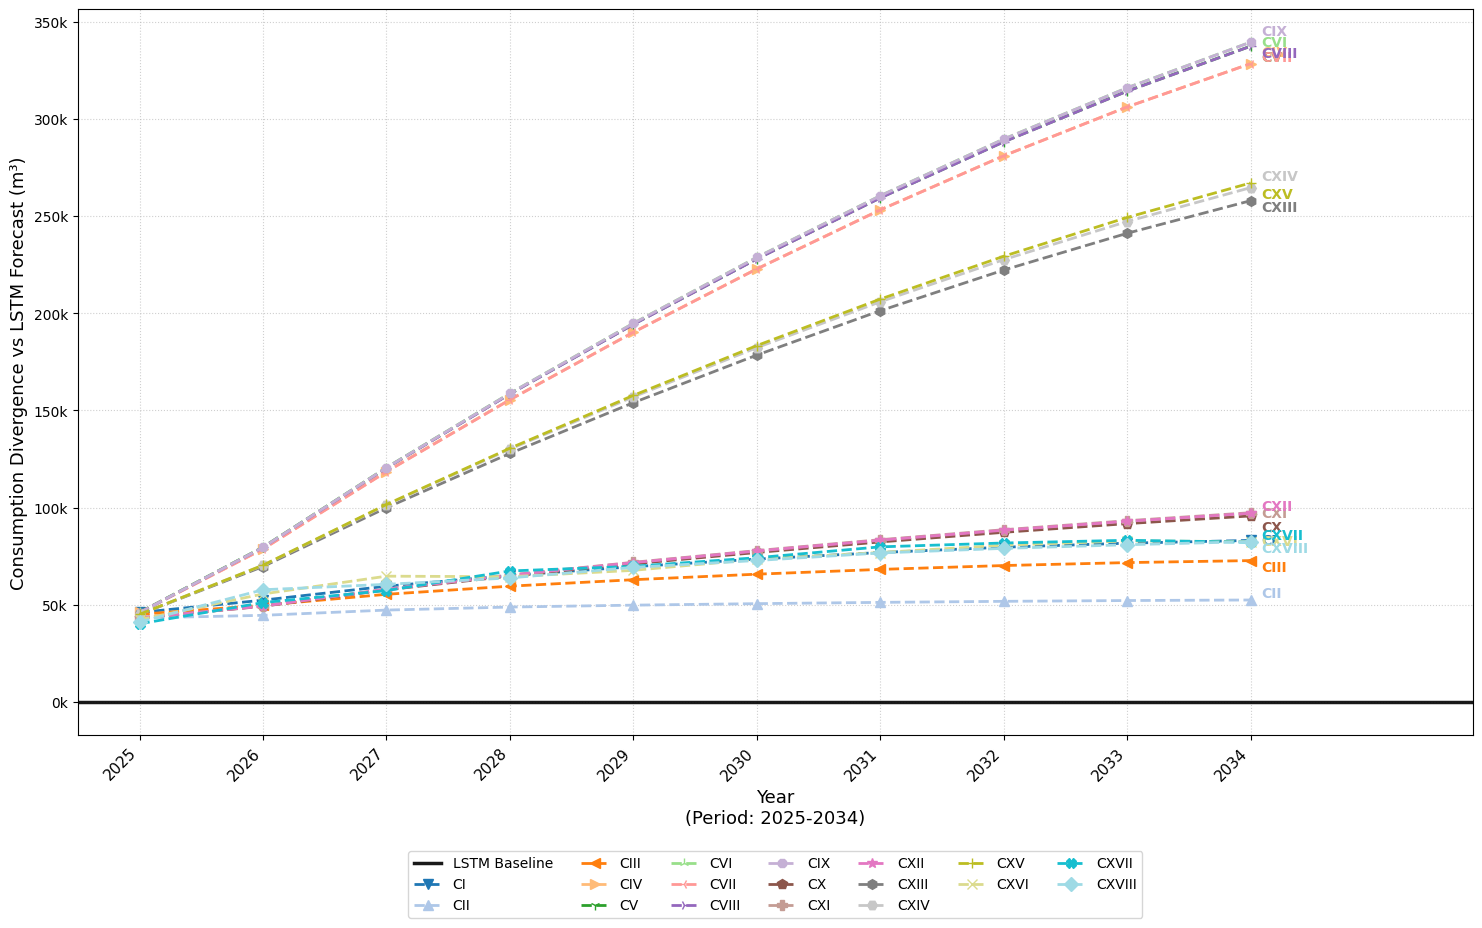

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import os

# ==========================================
# 1. Configuration and Paths
# ==========================================
# Define the base project directory
BASE_PATH = 'E:\\Projetos\\ABM-WP' 

# Input Files
SCENARIO_FILE = 'consumo_previsto_todos_cenarios.csv'
LSTM_FILE = 'previsoes_futuras_2025_2035.csv'

# Output File
OUTPUT_FILENAME = 'figure-diferenca-cenarios-vs-lstm-fig11.pdf'

# Directory Setup
INPUT_DIR_RES = os.path.join(BASE_PATH, 'resultados')
INPUT_DIR_MODELS = os.path.join(BASE_PATH, 'modelos IA')
INPUT_DIR_INC = os.path.join(BASE_PATH, 'includes')
OUTPUT_DIR = os.path.join(BASE_PATH, 'figuras')

def sum_yearly(df, date_col, value_cols):
    """ Helper to aggregate monthly data to annual sums """
    df_year = df.copy()
    df_year['Year'] = df_year[date_col].dt.year
    return df_year.groupby('Year')[value_cols].sum().reset_index()

def main():
    print("--- Starting Divergence Analysis: 18 Scenarios vs LSTM Baseline ---")

    # ==========================================
    # 2. Data Loading
    # ==========================================
    
    # A. Load Scenarios
    path_scenarios = os.path.join(INPUT_DIR_RES, SCENARIO_FILE)
    if not os.path.exists(path_scenarios):
        path_scenarios = os.path.join(INPUT_DIR_INC, SCENARIO_FILE)
    
    if not os.path.exists(path_scenarios):
        print(f"Error: Scenarios file not found: {path_scenarios}")
        return

    df_scenarios = pd.read_csv(path_scenarios, sep=';', decimal=',')
    
    # Date Construction
    if 'Mes' in df_scenarios.columns and 'Ano' in df_scenarios.columns:
        df_scenarios['Date'] = pd.to_datetime(df_scenarios['Ano'].astype(str) + '-' + 
                                            df_scenarios['Mes'].astype(str) + '-01')
    elif 'Mes_Ano' in df_scenarios.columns:
        df_scenarios['Date'] = pd.to_datetime(df_scenarios['Mes_Ano'], format='%m/%Y')
        
    scenario_cols = [c for c in df_scenarios.columns if c not in ['Mes', 'Ano', 'Mes_Ano', 'Date']]
    df_scenarios = df_scenarios[df_scenarios['Date'] <= pd.to_datetime('2034-12-31')]

    # B. Load LSTM
    path_lstm = os.path.join(INPUT_DIR_MODELS, LSTM_FILE)
    if not os.path.exists(path_lstm):
        print(f"Error: LSTM file not found: {path_lstm}")
        return
        
    df_lstm = pd.read_csv(path_lstm, parse_dates=['Data'])
    df_lstm = df_lstm.rename(columns={'Data': 'Date', 'Valor Previsto': 'LSTM'})
    df_lstm = df_lstm[df_lstm['Date'] <= pd.to_datetime('2034-12-31')]

    # ==========================================
    # 3. Calculation
    # ==========================================
    
    # Merge Scenario data with LSTM baseline
    df_combined = pd.merge(df_scenarios, df_lstm[['Date', 'LSTM']], on='Date', how='left')
    
    # Annual Aggregation
    all_numeric = scenario_cols + ['LSTM']
    df_annual = sum_yearly(df_combined, 'Date', all_numeric)
    
    # Calculate Differences (Scenario - LSTM Baseline)
    diff_cols = []
    for col in scenario_cols:
        diff_col_name = f"Diff_{col}"
        df_annual[diff_col_name] = df_annual[col] - df_annual['LSTM']
        diff_cols.append(diff_col_name)

    scenario_period = f"{df_annual['Year'].min()}-{df_annual['Year'].max()}"

    # ==========================================
    # 4. Plotting
    # ==========================================
    
    # Standard figure size consistent with Fig 10
    fig, ax = plt.subplots(figsize=(18, 11))
    
    # Reference line at y=0 (LSTM baseline equivalence)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=2.5, alpha=0.9, label='LSTM Baseline')

    # Visual Parameters (Same as Fig 10)
    markers_list = ['v', '^', '<', '>', '1', '2', '3', '4', '8', 'p', 'P', '*', 'h', 'H', '+', 'x', 'X', 'D']
    colors = plt.cm.tab20(np.linspace(0, 1, len(diff_cols)))
    label_offsets = [(8, 0), (8, 5), (8, -5), (8, 8), (8, -8)]

    for idx, col in enumerate(diff_cols):
        # Extract ID (e.g., "Diff_CI_..." -> "CI")
        original_name = col.replace("Diff_", "")
        scenario_id = original_name.split('_')[0]
        
        # Plot difference lines with high visibility (Alpha 1.0)
        ax.plot(df_annual['Year'], df_annual[col],
                color=colors[idx],
                linestyle='--',
                linewidth=2.0,
                alpha=1.0,
                marker=markers_list[idx % len(markers_list)],
                markersize=7,
                label=scenario_id)
        
        # Direct Labeling at the end of the series
        last_x = df_annual['Year'].iloc[-1]
        last_val = df_annual[col].iloc[-1]
        curr_offset = label_offsets[idx % len(label_offsets)]
        
        if not pd.isna(last_val):
             ax.annotate(scenario_id, 
                        (last_x, last_val), 
                        xytext=curr_offset, 
                        textcoords="offset points", 
                        ha='left', va='center',
                        fontsize=10, color=colors[idx], fontweight='bold')

    # ==========================================
    # 5. Formatting and Export
    # ==========================================
    
    # X-Axis
    ax.set_xticks(df_annual['Year'])
    ax.set_xticklabels(df_annual['Year'], rotation=45, ha='right', fontsize=11)
    
    # Y-Axis (Lower-case 'k' format for thousands)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1000:.0f}k'))
    
    # Limits and Labels
    ax.set_xlim(df_annual['Year'].min() - 0.5, df_annual['Year'].max() + 1.8)
    ax.set_xlabel(f"Year\n(Period: {scenario_period})", fontsize=13)
    ax.set_ylabel('Consumption Divergence vs LSTM Forecast (m³)', fontsize=13)
    
    # Grid Style (Consistent with Fig 10)
    plt.grid(True, linestyle=':', alpha=0.6)

    # Legend Layout (Using 'prop' to avoid fontweight TypeError)
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),
               ncol=7, frameon=True, fontsize=11, prop={'weight': 'normal'})

    plt.subplots_adjust(bottom=0.22)

    # Save Path
    if not os.path.exists(OUTPUT_DIR): os.makedirs(OUTPUT_DIR)
    full_output_path = os.path.join(OUTPUT_DIR, OUTPUT_FILENAME)
        
    plt.savefig(full_output_path, format='pdf', bbox_inches='tight')
    
    print(f"Success! Divergence chart saved at: {full_output_path}")
    plt.show()

if __name__ == "__main__":
    main()